# 01 Random Forest

In [1]:
%matplotlib inline
import json, os, warnings
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
warnings.filterwarnings("ignore")

from data_loader_00 import load_processed_data, get_Xy, get_combos

OUTPUT_DIR = os.path.join(os.getcwd(), "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)
RANDOM_SEED = 42
RF_PARAM_GRID = [
    {"n_estimators": n, "max_depth": d, "min_samples_leaf": l, "max_features": f}
    for n in [100, 300, 500]
    for d in [None, 10, 20]
    for l in [1, 5, 10]
    for f in ["sqrt", 0.5]
]

In [2]:
def calc_metrics(y_true, y_pred, label=""):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))) * 100
    denom = np.sum((y_true - y_true.mean()) ** 2)
    r2 = np.nan if denom == 0 else 1 - np.sum((y_true - y_pred) ** 2) / denom
    if label:
        print(f"[{label}] MAE={mae:,.2f} RMSE={rmse:,.2f} MAPE={mape:.3f}% R2={r2:.4f}")
    return {"MAE": round(mae, 2), "RMSE": round(rmse, 2), "MAPE": round(mape, 3), "R2": round(float(r2), 4)}

def tune_pooled_rf(train, valid, test, feature_cols):
    X_tr, y_tr = get_Xy(train, feature_cols)
    X_va, y_va = get_Xy(valid, feature_cols)
    X_te, y_te = get_Xy(test, feature_cols)
    results = []
    for params in RF_PARAM_GRID:
        model = RandomForestRegressor(**params, n_jobs=-1, random_state=RANDOM_SEED)
        model.fit(X_tr, y_tr)
        valid_preds = model.predict(X_va)
        valid_mae = mean_absolute_error(y_va, valid_preds)
        results.append({**params, "valid_MAE": round(valid_mae, 4)})
    df_res = pd.DataFrame(results).sort_values("valid_MAE").reset_index(drop=True)
    best_row = df_res.iloc[0]
    best_params = {
        "n_estimators": int(best_row["n_estimators"]),
        "max_depth": None if pd.isna(best_row["max_depth"]) else int(best_row["max_depth"]),
        "min_samples_leaf": int(best_row["min_samples_leaf"]),
        "max_features": best_row["max_features"],
    }
    X_trva = np.vstack([X_tr, X_va])
    y_trva = np.concatenate([y_tr, y_va])
    best_model = RandomForestRegressor(**best_params, n_jobs=-1, random_state=RANDOM_SEED)
    best_model.fit(X_trva, y_trva)
    test_preds = best_model.predict(X_te)
    return best_model, df_res, best_params, y_te, test_preds

def run_per_combo_rf(train, valid, test, feature_cols, best_params):
    combos = get_combos(train)
    all_preds, combo_rows = [], []
    for store, cat in combos:
        tr = train[(train["store_id"] == store) & (train["cat_id"] == cat)]
        va = valid[(valid["store_id"] == store) & (valid["cat_id"] == cat)]
        te = test[(test["store_id"] == store) & (test["cat_id"] == cat)]
        if len(te) == 0 or len(tr) == 0:
            continue
        fit_df = pd.concat([tr, va], ignore_index=True)
        X_fit, y_fit = get_Xy(fit_df, feature_cols)
        X_te, y_te = get_Xy(te, feature_cols)
        model = RandomForestRegressor(**best_params, n_jobs=-1, random_state=RANDOM_SEED)
        model.fit(X_fit, y_fit)
        preds = model.predict(X_te)
        m = calc_metrics(y_te, preds)
        m.update({"store_id": store, "cat_id": cat})
        combo_rows.append(m)
        pred_df = te[["week_start", "store_id", "cat_id"]].copy()
        pred_df["actual"] = y_te
        pred_df["predicted"] = preds
        all_preds.append(pred_df)
    preds_df = pd.concat(all_preds, ignore_index=True)
    combo_df = pd.DataFrame(combo_rows)
    overall = calc_metrics(preds_df["actual"], preds_df["predicted"], label="RF-PerCombo overall")
    return combo_df, preds_df, overall

In [3]:
train, valid, test, feature_cols = load_processed_data(valid_weeks=8)
best_rf, df_res, best_params, y_te, pooled_preds = tune_pooled_rf(train, valid, test, feature_cols)
combo_df, preds_df, percombo_metrics = run_per_combo_rf(train, valid, test, feature_cols, best_params)
pooled_metrics = calc_metrics(y_te, pooled_preds, label="RF-Pooled test")
print(best_params)

[load] Train=6,270 | Valid=240 | Test=240 | Features=39
[RF-PerCombo overall] MAE=597.19 RMSE=1,103.62 MAPE=5.652% R2=0.9814
[RF-Pooled test] MAE=448.51 RMSE=805.99 MAPE=4.496% R2=0.9901
{'n_estimators': 300, 'max_depth': 20, 'min_samples_leaf': 1, 'max_features': 0.5}


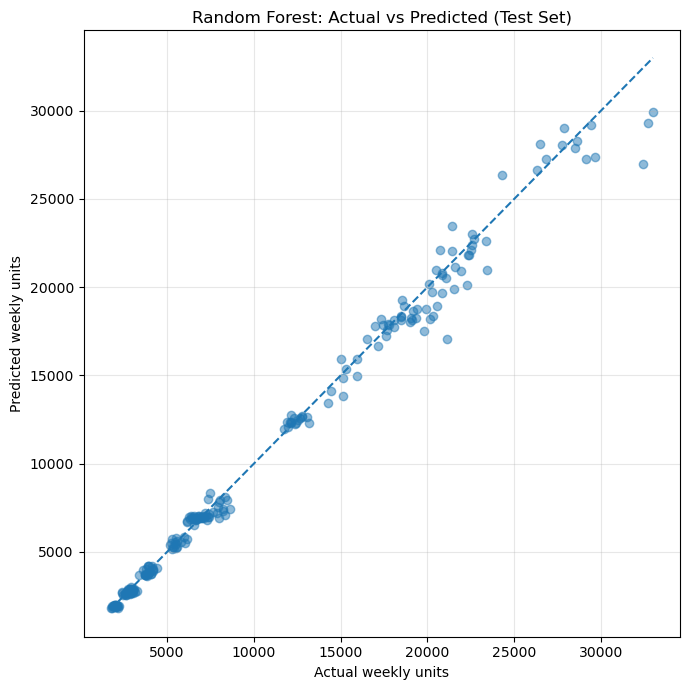

In [4]:
X_te, y_te = get_Xy(test, feature_cols)
pooled_preds = best_rf.predict(X_te)

plt.figure(figsize=(7, 7))
plt.scatter(y_te, pooled_preds, alpha=0.5)
min_val = min(np.min(y_te), np.min(pooled_preds))
max_val = max(np.max(y_te), np.max(pooled_preds))
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.title("Random Forest: Actual vs Predicted (Test Set)")
plt.xlabel("Actual weekly units")
plt.ylabel("Predicted weekly units")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
joblib.dump(best_rf, os.path.join(OUTPUT_DIR, "rf_pooled_best_model.joblib"))
df_res.to_csv(os.path.join(OUTPUT_DIR, "rf_sensitivity_table.csv"), index=False)
combo_df.to_csv(os.path.join(OUTPUT_DIR, "rf_combo_results.csv"), index=False)
preds_df.to_csv(os.path.join(OUTPUT_DIR, "rf_percombo_predictions.csv"), index=False)
print("Saved RF outputs.")

Saved RF outputs.
